<a href="https://colab.research.google.com/github/frankZawacki/DSP566GroupProj_Colab/blob/groupProject/CancerDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
%pip install kaggle
%pip install kagglehub

In [17]:
!mkdir -p ~/.kaggle

In [18]:
!cp /content/kaggle.json ~/.kaggle/

In [19]:
!chmod 600 ~/.kaggle/kaggle.json
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

In [21]:
import kagglehub

In [22]:
#import kaggle

OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/

In [23]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy # Explicitly import for clarity
from tensorflow.keras.applications import ResNet50V2 # The chosen pre-trained model
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess_input # Model-specific preprocessing

import os # Ensure os is imported for path handling

# --- Configuration (Ensure these match your project's settings) ---
# Assuming these are defined globally or passed into the function context
IMG_HEIGHT = 224 # Standard input size for many pre-trained models
IMG_WIDTH = 224  # Standard input size for many pre-trained models
BATCH_SIZE = 32
EPOCHS = 50 # EarlyStopping will stop training when validation loss plateaus
classification_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

In [24]:
train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess_input, # <--- CRITICAL: Model-specific preprocessing
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess_input # <--- CRITICAL: Model-specific preprocessing
)

In [25]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(classification_path, 'Training'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='rgb', # <--- CRITICAL: Pre-trained models expect 3 channels
    class_mode='categorical' # <--- CRITICAL: Use categorical for one-hot labels
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(classification_path, 'Testing'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='rgb', # <--- CRITICAL: Pre-trained models expect 3 channels
    class_mode='categorical',
    shuffle=False # Keep shuffle=False for consistent evaluation (e.g., confusion matrix)
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [26]:
from tensorflow.keras.applications import ResNet50V2

In [27]:
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
print(f"Detected Classes: {class_labels}")

# --- Building CNN Model with ResNet50V2 Pre-trained Base ---
print("\n--- Building CNN Model with ResNet50V2 Pre-trained Base ---")

# 1. Load the pre-trained convolutional base (ResNet50V2)
# include_top=False: We don't want ResNet's original classification head
# weights='imagenet': Use weights pre-trained on the ImageNet dataset
# input_shape: Must match your target_size and color_mode (e.g., (224, 224, 3))
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# 2. Strategy 1: Feature Extraction - Freeze the entire convolutional base
# This means the weights of ResNet50V2 will NOT be updated during training.
# This is a good starting point, especially if your dataset is relatively small.
base_model.trainable = False

# 3. Create your custom classification head on top of the frozen base
# The Functional API is often preferred for more complex models, but Sequential works too.
# Let's build a functional model for clarity on connecting layers.
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False) # Pass inputs through the base model (training=False ensures batch_norm behaves correctly)
x = Flatten()(x) # Flatten the output of the convolutional base
x = Dropout(0.5)(x) # Increased dropout for initial regularization
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x) # Helps stabilize training
x = Dropout(0.3)(x) # Another dropout layer
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

Detected Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

--- Building CNN Model with ResNet50V2 Pre-trained Base ---
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [28]:
# 4. Compile the model
# Use a relatively low learning rate for Adam, as we're only training the new layers.
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Lower learning rate is often better for transfer learning
    loss=CategoricalCrossentropy(), # <--- CRITICAL: Use CategoricalCrossentropy for one-hot labels
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,257,220 (187.90 MB)

 Trainable params: 25,691,908 (98.01 MB)

 Non-trainable params: 23,565,312 (89.89 MB)

In [29]:
# --- Training the Model ---
print("\n--- Training the Model (Feature Extraction Phase) ---")
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr]
)



--- Training the Model (Feature Extraction Phase) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 154s 788ms/step - accuracy: 0.7297 - loss: 0.8218 - val_accuracy: 0.8797 - val_loss: 0.4148 - learning_rate: 1.0000e-04
Epoch 2/50
  1/178 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7500 - loss: 0.5242

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7500 - loss: 0.5242 - val_accuracy: 0.8750 - val_loss: 0.4228 - learning_rate: 1.0000e-04
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 68s 379ms/step - accuracy: 0.8530 - loss: 0.4214 - val_accuracy: 0.9016 - val_loss: 0.2793 - learning_rate: 1.0000e-04
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9062 - loss: 0.3715 - val_accuracy: 0.9039 - val_loss: 0.2779 - learning_rate: 1.0000e-04
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 67s 378ms/step - accuracy: 0.8924 - loss: 0.3180 - val_accuracy: 0.9055 - val_loss: 0.2864 - learning_rate: 1.0000e-04
Epoch 6/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9062 - loss: 0.3138 - val_accuracy: 0.9062 - val_loss: 0.2843 - learning_rate: 1.0000e-04
Epoch 7/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 67s 379ms/step - accuracy: 0.9030 - loss: 0.2566 - val_accuracy: 0.9187 - val_loss: 0.2343 - learning_rate: 1.0000e-04
Epoch 8/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy

In [30]:
# --- Optional: Fine-tuning Phase (Highly Recommended for Better Performance) ---
print("\n--- Starting Fine-tuning Phase (Unfreezing some layers) ---")

# Unfreeze the base model. Note that it still contains BatchNormalization layers.
# BatchNormalization layers are tricky when fine-tuning. For small batch sizes or if you
# don't want their statistics to change, it's often better to keep them frozen.
# Keras's `training=False` when calling `base_model` handles this in the initial phase.
# Now, we'll unfreeze the whole base model and set base_model.trainable = True.
# The base model was passed with `training=False` in the above `model = Model(...)` call.
# To truly fine-tune its internal BatchNormalization layers or if you re-compile/re-train it
# in a separate step without the initial `training=False` setting, they will update.
# For simplicity and common practice, we'll unfreeze the whole base model now.

base_model.trainable = True # Now the base model's weights will be updated

# It's good practice to set a very low learning rate for fine-tuning
# as you're adjusting pre-trained weights gently.
model.compile(
    optimizer=Adam(learning_rate=0.00001), # <--- VERY LOW LEARNING RATE for fine-tuning
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary() # Check trainable parameters again - should be much higher now


--- Starting Fine-tuning Phase (Unfreezing some layers) ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,257,220 (187.90 MB)

 Trainable params: 49,211,268 (187.73 MB)

 Non-trainable params: 45,952 (179.50 KB)

In [31]:
# Continue training for a few more epochs with the fine-tuned model
# You might want a separate EarlyStopping callback for fine-tuning if needed.
history_fine_tune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS, # You can set a different number of epochs for fine-tuning
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr] # Reuse or define new callbacks
)

Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 143s 524ms/step - accuracy: 0.8442 - loss: 0.4921 - val_accuracy: 0.8984 - val_loss: 0.2934 - learning_rate: 1.0000e-05
Epoch 2/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8438 - loss: 0.2924 - val_accuracy: 0.9000 - val_loss: 0.2929 - learning_rate: 1.0000e-05
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 68s 381ms/step - accuracy: 0.9043 - loss: 0.2833 - val_accuracy: 0.9016 - val_loss: 0.2820 - learning_rate: 1.0000e-05
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8438 - loss: 0.4058 - val_accuracy: 0.8992 - val_loss: 0.2828 - learning_rate: 1.0000e-05
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 68s 383ms/step - accuracy: 0.9195 - loss: 0.2257 - val_accuracy: 0.9383 - val_loss: 0.1747 - learning_rate: 1.0000e-05
Epoch 6/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9375 - loss: 0.1861 - val_accuracy: 0.9383 - val_loss: 0.1733 - learning_rate: 1.0000e-05
Epoch 7/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 69s 389ms/s

In [32]:
# --- Evaluation and Plotting (as before) ---
print("\n--- Evaluating the Final Model ---")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# You'll need to combine the history objects if you want to plot continuous curves
# for accuracy and loss across both phases.
# For example:
# total_accuracy = history.history['accuracy'] + history_fine_tune.history['accuracy']
# total_val_accuracy = history.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
# total_loss = history.history['loss'] + history_fine_tune.history['loss']
# total_val_loss = history.history['val_loss'] + history_fine_tune.history['val_loss']


--- Evaluating the Final Model ---
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 165ms/step - accuracy: 0.9949 - loss: 0.0226
Test Loss: 0.0235, Test Accuracy: 0.9939


In [33]:
import matplotlib.pyplot as plt
import numpy as np

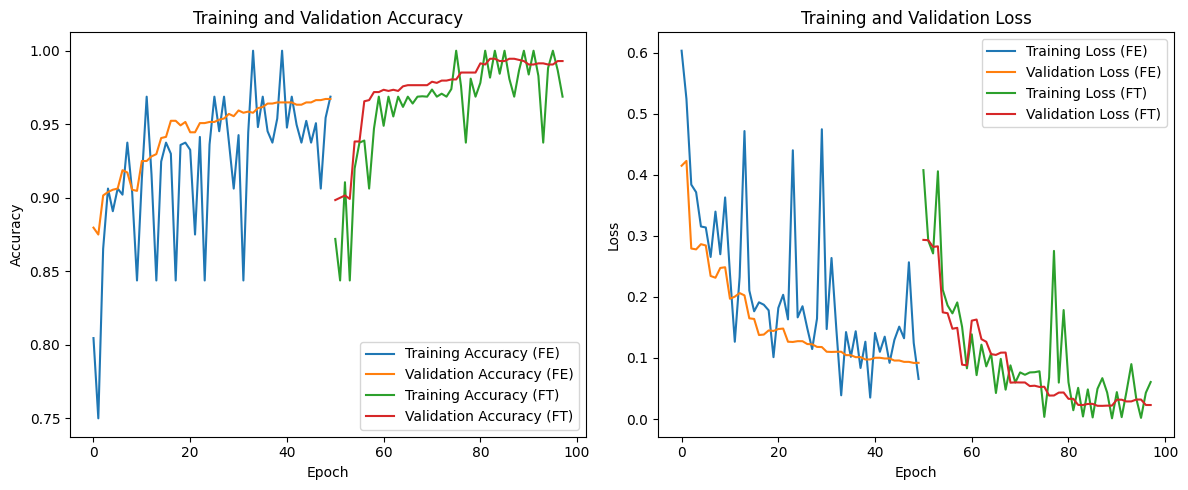

In [34]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy (FE)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (FE)')
if 'history_fine_tune' in locals():
    plt.plot(range(len(history.history['accuracy']), len(history.history['accuracy']) + len(history_fine_tune.history['accuracy'])),
             history_fine_tune.history['accuracy'], label='Training Accuracy (FT)')
    plt.plot(range(len(history.history['val_accuracy']), len(history.history['val_accuracy']) + len(history_fine_tune.history['val_accuracy'])),
             history_fine_tune.history['val_accuracy'], label='Validation Accuracy (FT)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss (FE)')
plt.plot(history.history['val_loss'], label='Validation Loss (FE)')
if 'history_fine_tune' in locals():
    plt.plot(range(len(history.history['loss']), len(history.history['loss']) + len(history_fine_tune.history['loss'])),
             history_fine_tune.history['loss'], label='Training Loss (FT)')
    plt.plot(range(len(history.history['val_loss']), len(history.history['val_loss']) + len(history_fine_tune.history['val_loss'])),
             history_fine_tune.history['val_loss'], label='Validation Loss (FT)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()



--- Generating Classification Report and Confusion Matrix ---
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       300
  meningioma       0.98      0.99      0.99       306
     notumor       1.00      1.00      1.00       405
   pituitary       1.00      0.99      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



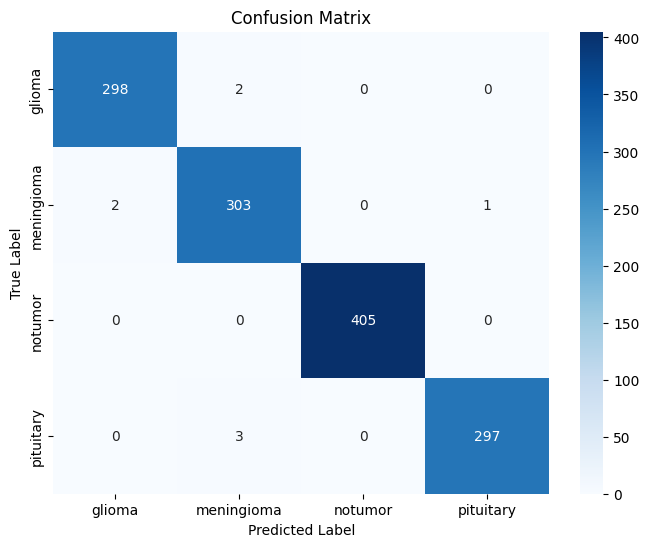

In [35]:
print("\n--- Generating Classification Report and Confusion Matrix ---")
test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true_classes = test_generator.classes

# Need to map integer labels back to class names for the report
true_class_names = [class_labels[idx] for idx in y_true_classes]
predicted_class_names = [class_labels[idx] for idx in y_pred_classes]
print("\nClassification Report:")
from sklearn.metrics import classification_report, confusion_matrix # Ensure these are imported
print(classification_report(true_class_names, predicted_class_names, target_names=class_labels))

conf_matrix = confusion_matrix(true_class_names, predicted_class_names)
import seaborn as sns # Ensure seaborn is imported for heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title('Confusion Matrix')
plt.show()